In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

<>:124: SyntaxWarning: invalid escape sequence '\p'
<>:144: SyntaxWarning: invalid escape sequence '\p'
<>:124: SyntaxWarning: invalid escape sequence '\p'
<>:144: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ibane\AppData\Local\Temp\ipykernel_20596\3672288498.py:124: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_title('Funciones de Onda $\psi_n(x)$', fontsize=16, color='yellow')
C:\Users\ibane\AppData\Local\Temp\ipykernel_20596\3672288498.py:144: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_title('Densidad de Probabilidad $|\psi_n(x)|^2$', fontsize=16, color='lime')


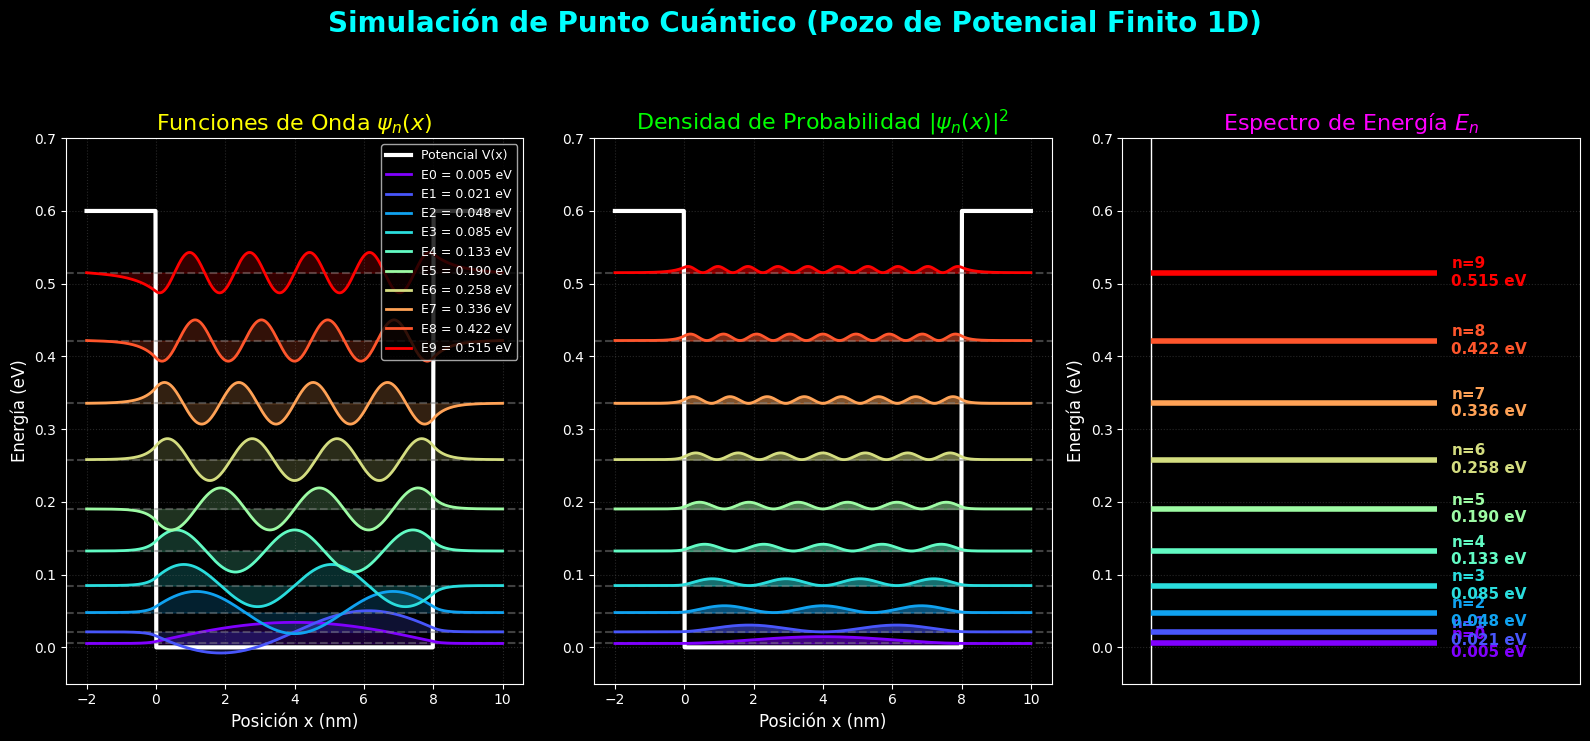

In [24]:
# =============================================================
# Quantum dot as a 1D finite potential well
#
# V(x) = 0      for 0 < x < L
#      = V0     for x <= 0 or x >= L
#
# Stationary Schrödinger equation:
#
# [ -(h²/2m) d²/dx² + V(x) ] ψ(x) = E ψ(x)
#
# In convenient units:
# - length in nm
# - energy in eV
#
# For an electron:
# h²/(2m_e) = 0.0380998212 eV·nm²
# =============================================================



#constants

K = 0.0390998212 #eV * nm^2 // h^2 / (2m_e)

def finite_well_simulation(L, V0, N = 520, padding = 2.0):

    """
    Solve the 1D finite square well with a finite-difference Hamiltonian.

    Parameters
    ----------
    L : float
        Width of the well in nm.
    V0 : float
        Barrier height in eV.
    N : int
        Number of grid points.
    padding : float
        Extra space outside the well, in nm.

    Returns
    -------
    x : ndarray
        Position grid in nm.
    V : ndarray
        Potential profile in eV.
    E_bound : ndarray
        Bound-state energies (E < V0), in eV.
    psi_bound : ndarray
        Corresponding normalized eigenfunctions.
    """

    #Space work

    x_min, x_max = -padding, L + padding
    x = np.linspace(x_min, x_max,N)
    dx = x[1] - x[0]

    # Potential (definir el potencial a trozos)
    V = np.where( (x>0) & (x<L), 0.0, V0)

    # Matrix definition
    main_diag = np.full(N, 2.0)
    off_diag = np.full(N-1, -1.0)

    kinetic_prefactor = K / dx**2

    
    # Hamiltonian matrix
    H = np.diag(kinetic_prefactor * main_diag + V)
    H += np.diag(kinetic_prefactor * off_diag, 1)
    H += np.diag(kinetic_prefactor * off_diag, -1)

    #Diagonalize (eigenVALUES , eigenVECTORS)
    evals, evecs = np.linalg.eigh(H)

    # Bound states satisfy E < V0
    mask = evals < V0  #We select the eigen values that fall within the potential
    E_bound = evals[mask] # The bounded energies are contained in the list of evals
    psi_bound = evecs[:, mask] # The eigen vectores associated with the bounded energy levels

    # Normalize wavefunctions: ∫|ψ|² dx = 1
    for i in range(psi_bound.shape[1]):
        norm = np.sqrt(np.trapezoid(np.abs(psi_bound[:, i])**2, x))
        psi_bound[:, i] /= norm

    return x, V, E_bound, psi_bound


# =============================================================
# SECCIÓN DE GRÁFICAS CHULAS (ESTILO NEÓN / DARK MODE)
# =============================================================

# Ejecutamos la simulación
L, V0 = 8.0, 0.6
x, V, E_bound, psi_bound = finite_well_simulation(L=L, V0=V0)

# Configuración de estilo
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 8))
fig.suptitle('Simulación de Punto Cuántico (Pozo de Potencial Finito 1D)', 
             fontsize=20, fontweight='bold', color='cyan', y=0.95)

# Paleta de colores neón para los estados
colors = plt.cm.rainbow(np.linspace(0, 1, len(E_bound)))

# Factores de escala visual para que las ondas no se salgan del gráfico
scale_psi = 0.06
scale_prob = 0.04

# --- GRÁFICO 1: Funciones de onda (psi) ---
ax1 = plt.subplot(1, 3, 1)
ax1.plot(x, V, color='white', linewidth=3, label='Potencial V(x)')

for i, E in enumerate(E_bound):
    # Desplazamos la onda para que flote sobre su nivel de energía
    psi_shifted = E + psi_bound[:, i] * scale_psi
    
    ax1.axhline(E, color='gray', linestyle='--', alpha=0.5)
    ax1.plot(x, psi_shifted, color=colors[i], linewidth=2, label=f'E{i} = {E:.3f} eV')
    # Relleno difuminado para un efecto "brillo"
    ax1.fill_between(x, E, psi_shifted, color=colors[i], alpha=0.2)

ax1.set_title('Funciones de Onda $\psi_n(x)$', fontsize=16, color='yellow')
ax1.set_xlabel('Posición x (nm)', fontsize=12)
ax1.set_ylabel('Energía (eV)', fontsize=12)
ax1.set_ylim(-0.05, V0 + 0.1)
ax1.grid(color='gray', linestyle=':', alpha=0.3)

# --- GRÁFICO 2: Densidades de Probabilidad (|psi|^2) ---
ax2 = plt.subplot(1, 3, 2)
ax2.plot(x, V, color='white', linewidth=3)

for i, E in enumerate(E_bound):
    # Calculamos |psi|^2
    prob_density = np.abs(psi_bound[:, i])**2
    prob_shifted = E + prob_density * scale_prob
    
    ax2.axhline(E, color='gray', linestyle='--', alpha=0.5)
    ax2.plot(x, prob_shifted, color=colors[i], linewidth=2)
    # Relleno sólido indicando la probabilidad de encontrar al electrón
    ax2.fill_between(x, E, prob_shifted, color=colors[i], alpha=0.5)

ax2.set_title('Densidad de Probabilidad $|\psi_n(x)|^2$', fontsize=16, color='lime')
ax2.set_xlabel('Posición x (nm)', fontsize=12)
ax2.set_ylim(-0.05, V0 + 0.1)
ax2.grid(color='gray', linestyle=':', alpha=0.3)

# --- GRÁFICO 3: Espectro de Energías ---
ax3 = plt.subplot(1, 3, 3)
ax3.axvline(0, color='white', linewidth=1)

for i, E in enumerate(E_bound):
    ax3.hlines(E, 0, 1, colors=colors[i], linewidth=4)
    ax3.text(1.05, E, f'n={i}\n{E:.3f} eV', color=colors[i], va='center', fontsize=11, fontweight='bold')

ax3.set_title('Espectro de Energía $E_n$', fontsize=16, color='magenta')
ax3.set_ylabel('Energía (eV)', fontsize=12)
ax3.set_xticks([])
ax3.set_xlim(-0.1, 1.5)
ax3.set_ylim(-0.05, V0 + 0.1)
ax3.grid(color='gray', linestyle=':', alpha=0.3)

# Leyenda global en el primer gráfico
ax1.legend(loc='upper right', fontsize=9, facecolor='black', framealpha=0.8)

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()